# Assignment 1 (15%): Due Friday Week 4, 11:55pm

This assessment will cover content taught in the week 1-3 Workshops and Applied classes. 

Each task will be graded on;
- Correctness of code & math
- Quality of results and presentation
- Quality of analysis and reasoning

Submit a .pdf with all the results produced and your analysis of said results as well as runnable Python, MATLAB or Julia code, which should reproduce the results you submit in the .pdf file. 

# Part 0: Problem Selection (1 Mark)

In this assignment we will develop some of the skills that a computational scientist will use. 

Imagine that a client of yours has asked you to develop a method for numerically estimating a real world phenomena. Select one real world phenomenon described by a closed-form function with exactly one independant variable. The function *must* include *at least one* of the following elementary functions; $\sin, \cos, \tan, \exp, \log$. Some potential examples include, but are not limited to;

- The damped pendulum function: $\theta(t) = \theta_0e^{-\gamma t}\cos(\sqrt{\omega^2 - \gamma^2} t)$

- The continuous logistic growth function: $P(t) = \frac{K}{(\frac{K}{P_0}-1)e^{-rt} + 1}$

- Tide hight: $h(t) = h_0 + A_1 \cos(\omega_1t + \phi_1) + A_2\cos(\omega_2t + \phi_2)$

- Newton's law of cooling: $T(t) = T_{env} + (T_0 - T_{env})e^{-kt}$

Tell us about the function that you chose: Why is it interesting to you? What do the variables and constants in the function describe?

(Note: Any of the examples given above is a valid choice. You do not need to choose phenomena from outside this list in order to get full marks.)

### Answer
I chose Newton's law of cooling. It is a law to model the rate of an object cools or heats up when the object is hotter or cooler than its environment. If the temperature is small and other factors don't change, the constant heat transfer coefficient helps us predict how heat flow. It is interesting as it used in forensic science to determine the time of death based on body temperature and to measure the rate of cooling with respect to temperature. 

- $T$ : Temperature of the object at a given time
- $T_{env}$ : ambient temperature
- $T_0$ : initial temperature
- $k$ : Rate constant known as the cooling factor

In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Part 1: Exact Solution (2 Marks)

Select a region of interest from the domain and produce **two plots** showing how the behaviour of the chosen system changes as the exogenous variables change. What insights can you draw from these plots about the behaviour of the system? Justify and explain your choices and results.

### Answer

I chose $T_{env}$ and $k$ as my exogenous variables. As exogenous variables is about external factors and I am curious how the temperature of the environment and the cooling rate such as difference between metal and ceramic cup will affect the change the rate of how fast an object cools. 

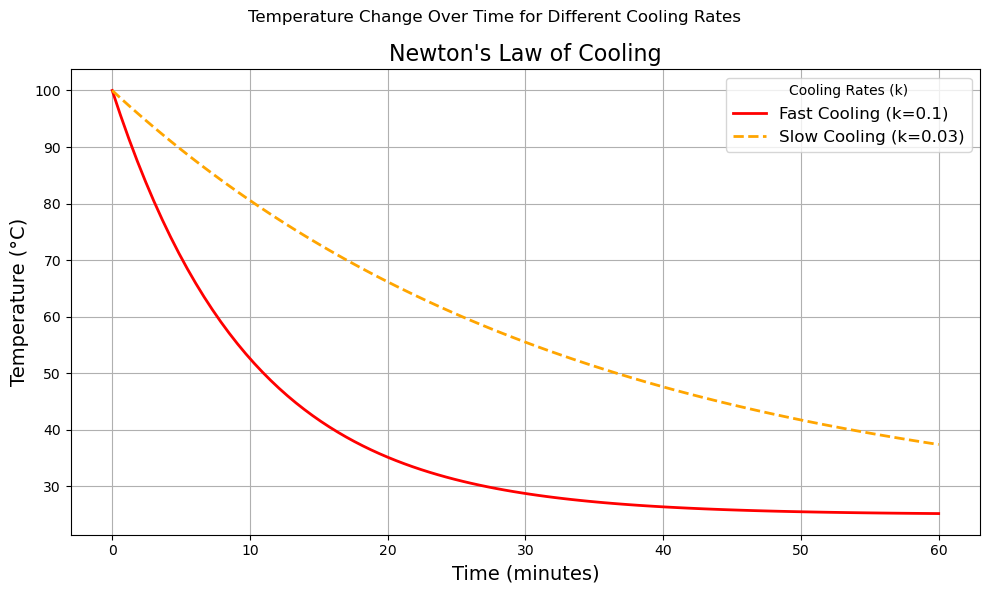

In [62]:
# Newton's Law of Cooling
def newton_cooling(t,T0,T_env,k):
    return T_env + (T0 - T_env) * np.exp(-k*t)

# Time range
t = np.linspace(0, 60, 100)

# Initial conditions
T0 = 100 # Initial temperature (boiling water)
T_env1 = 25 # Room temperature
T_env2 = 5 # Fridge temperature

# Varying cooling rate (k different)
k_fast = 0.1 # Fast cooling (metal cup)
k_slow = 0.03 # ceramic mug (ceramic cup)

# Compute temperature over time for different cooling rates (k values)
T_fast = newton_cooling(t,T0,T_env1,k_fast)
T_slow = newton_cooling(t,T0,T_env1,k_slow)

# Create the plot
plt.figure(figsize=(10, 6))  
plt.plot(t, T_fast, label=f'Fast Cooling (k={k_fast})', color='red', linestyle='-', linewidth=2)
plt.plot(t, T_slow, label=f'Slow Cooling (k={k_slow})', color='orange', linestyle='--', linewidth=2)

# Add title and labels
plt.title("Newton's Law of Cooling", fontsize=16)
plt.suptitle("Temperature Change Over Time for Different Cooling Rates", fontsize=12)
plt.xlabel("Time (minutes)", fontsize=14)
plt.ylabel("Temperature (°C)", fontsize=14)

# Add a grid and legend
plt.grid(True)
plt.legend(title="Cooling Rates (k)", fontsize=12)

# Display the plot
plt.tight_layout()  
plt.show()

#### Behaviour
This first plot demonstrates how different cooling rates affects the temperature of the object change over time. Higher cooling rates ($k$ = 0.1), such that boiling water is placed in a metal cup, allow the object to cool faster and steeper temperature drop, while lower cooling rates such that placing boiling water in a ceramic cup ($k$ = 0.03) allows the object to cool slower and not as steep. However, both curves do not reach zero but it's approaching the ambient temperature (25°C). When it has higher cooling rates ($k$ = 0.1), it took about 25-30 minutes to reach the ambient temperature while lower cooling rates ($k$ = 0.03) took more than 60 minutes to reach the ambient temperature. 

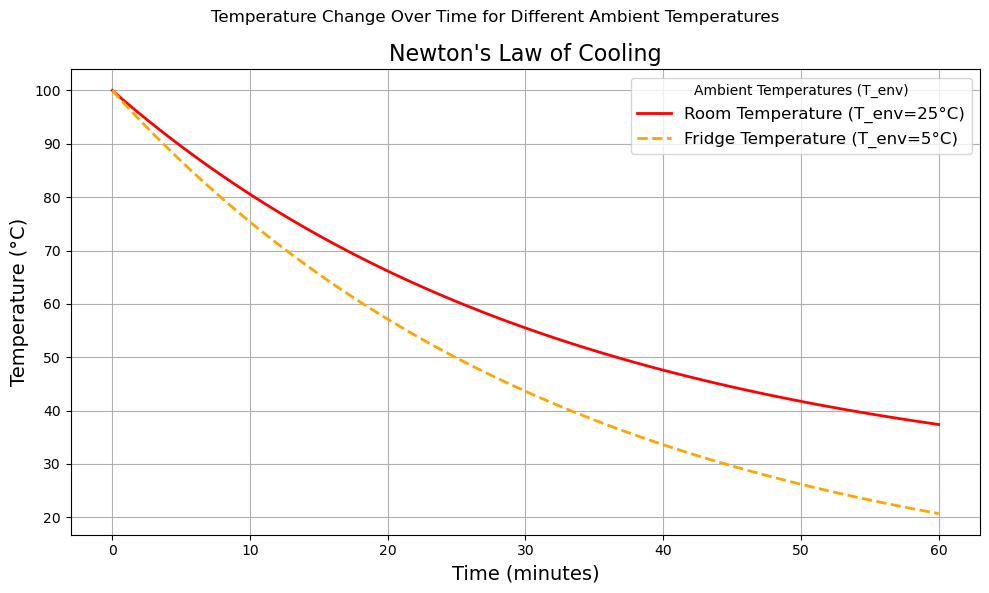

In [63]:
# Compute temp over time for different ambient temp
T_room = newton_cooling(t,T0,T_env1,k_slow)
T_fridge = newton_cooling(t,T0,T_env2,k_slow)

# Create the plot
plt.figure(figsize=(10, 6)) 
plt.plot(t, T_room, label=f'Room Temperature (T_env={T_env1}°C)', color='red', linestyle='-', linewidth=2)
plt.plot(t, T_fridge, label=f'Fridge Temperature (T_env={T_env2}°C)', color='orange', linestyle='--', linewidth=2)

# Add title and labels
plt.title("Newton's Law of Cooling", fontsize=16)
plt.suptitle("Temperature Change Over Time for Different Ambient Temperatures", fontsize=12)
plt.xlabel("Time (minutes)", fontsize=14)
plt.ylabel("Temperature (°C)", fontsize=14)

# Add a grid and legend
plt.grid(True)
plt.legend(title="Ambient Temperatures (T_env)", fontsize=12)

# Display the plot
plt.tight_layout()  
plt.show()

#### Behaviour
This second plot demonstrates how the ambient temperature affects the temperature of the object change over time. When the ambient temperature is lower (like in the fridge, $T_{env2}$ = 5°C), the object cools faster resulting faster temperature drop (steeper cooling curve). In contrast, when the ambient temperature is higher (like in the room, $T_{env1}$ = 25°C), the object cools slower. Within 60 minutes, the object in the room (represented by the red curve) managed to reach around 40°C while the object in the fridge (represented by the orange curve) reached about 20°C. Over time, both will approach their ambient temperatures: the object in the fridge will approach 5°C while the object in the room will approach 25°C.

#### Conclusion
Both plots illustrate how the cooling process of an object is influneced by two exogenous variables: $T_{env}$ and $k$. The two plot aligns with the Newton's law of cooling describes an exponential decrease in the temperature difference between an object and its surroundings over time. 

In the first plot, a higher cooling rate leads to a faster temperature decline and steeper curve whereas a lower cooling rate leads to a slower temperature decline and gradual curve.

In the second plot, lower ambient temperature causes faster cooling as there is a greater temperature difference between the object and its surroundings which allows an object to reach a lower temperature quickly. Conversely, higher ambient temperature results in slower cooling.

# Part 2: Introducing Modelling Errors  (3 Marks)

The computer in which your code will be deployed is limited. It cannot actually compute the $\sin, \cos, \tan, \exp, \log$ functions and must instead approximate them with a Taylor Series Expansion, truncated after the first two nonzero terms, centred on some point in the region of interest you chose in Part 1. 

You wish to know how much your model's accuracy will be impacted before it is deployed, and so have decided to simulate the result on your computer. 
Modify your code from part 1 to take this into account. Explore the same space you did in part 1 with new plots. Explain how and why does the behaviour change?

### Answer

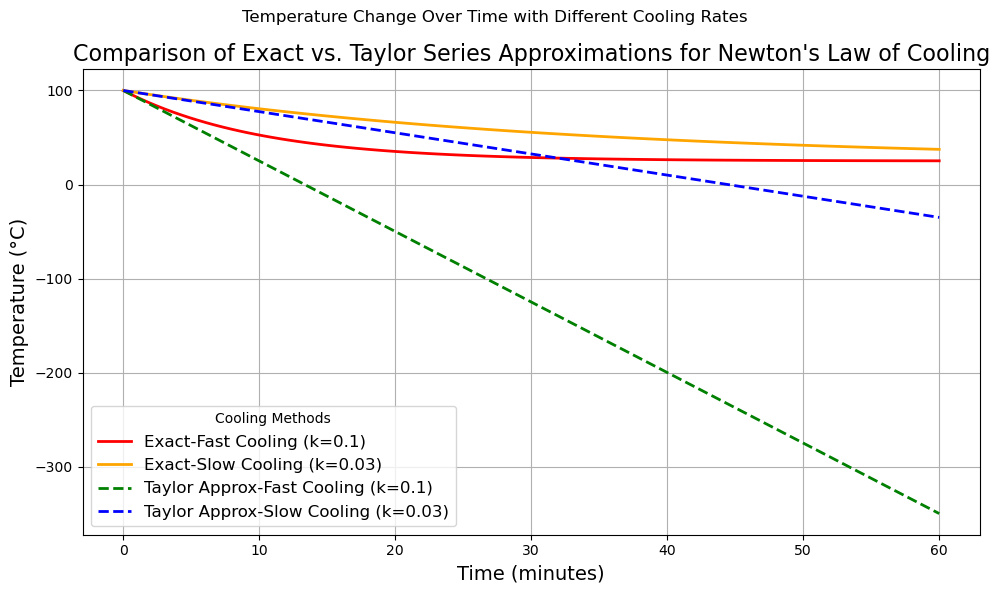

In [28]:
# Taylor series approximation of e^(-kt): 1 - kt; First two nonzero terms
def newton_cooling_taylor(t,T0,T_env,k):
    return T_env + (T0 - T_env) * (1 - k*t)

def newton_cooling(t,T0,T_env,k):
    return T_env + (T0 - T_env) * np.exp(-k*t)

# Time range & parameters
t = np.linspace(0, 60, 100)
T0 = 100
T_env1 = 25
T_env2 = 5
k_fast = 0.1
k_slow = 0.03  

# Compute temperatures over time with different cooling rates 
# Exact approximations
T_fast = newton_cooling(t,T0,T_env1,k_fast)
T_slow = newton_cooling(t,T0,T_env1,k_slow)
# Taylor series approximations
T_fast_taylor = newton_cooling_taylor(t,T0,T_env1,k_fast)
T_slow_taylor = newton_cooling_taylor(t,T0,T_env1,k_slow)

# Create the plot
plt.figure(figsize=(10, 6))  

# Plot the exact solutions 
plt.plot(t, T_fast, label=f'Exact-Fast Cooling (k={k_fast})', color='red', linestyle='-', linewidth=2)
plt.plot(t, T_slow, label=f'Exact-Slow Cooling (k={k_slow})', color='orange', linestyle='-', linewidth=2)

# Plot the Taylor series approximations 
plt.plot(t, T_fast_taylor, label=f'Taylor Approx-Fast Cooling (k={k_fast})', color='green', linestyle='--', linewidth=2)
plt.plot(t, T_slow_taylor, label=f'Taylor Approx-Slow Cooling (k={k_slow})', color='blue', linestyle='--', linewidth=2)

# Add title and labels
plt.title("Comparison of Exact vs. Taylor Series Approximations for Newton's Law of Cooling", fontsize=16)
plt.suptitle("Temperature Change Over Time with Different Cooling Rates", fontsize=12)
plt.xlabel("Time (minutes)", fontsize=14)
plt.ylabel("Temperature (°C)", fontsize=14)

# Add a grid and legend
plt.grid(True)

plt.legend(title="Cooling Methods", fontsize=12)

# Display the plot
plt.tight_layout() 
plt.show()

#### Behaviour
The exact solutions using Newton’s Law of Cooling (represented by red and orange curves) follow an exponential decay which shows the cooling slows down over time and asymptotically approaches the ambient temperatures. The approximate solutions of Taylor series expansion using only the first two nonzero terms (represented by blue and green curves) are linear which are the result of straight-line approximation. It does not capture the asymptotic behaviour of the exponential function. Initially, it works well for small values of $t$ (around 5-10 minutes), but as $t$ increases, the approximation gets worse. Especially the Taylor series approximation for higher cooling rates ($k$ = 0.1), where the temperature decreases rapidly and constantly into negative temperature which is unrealistic. In contrast, the exponential function never decreases below the ambient temperature.

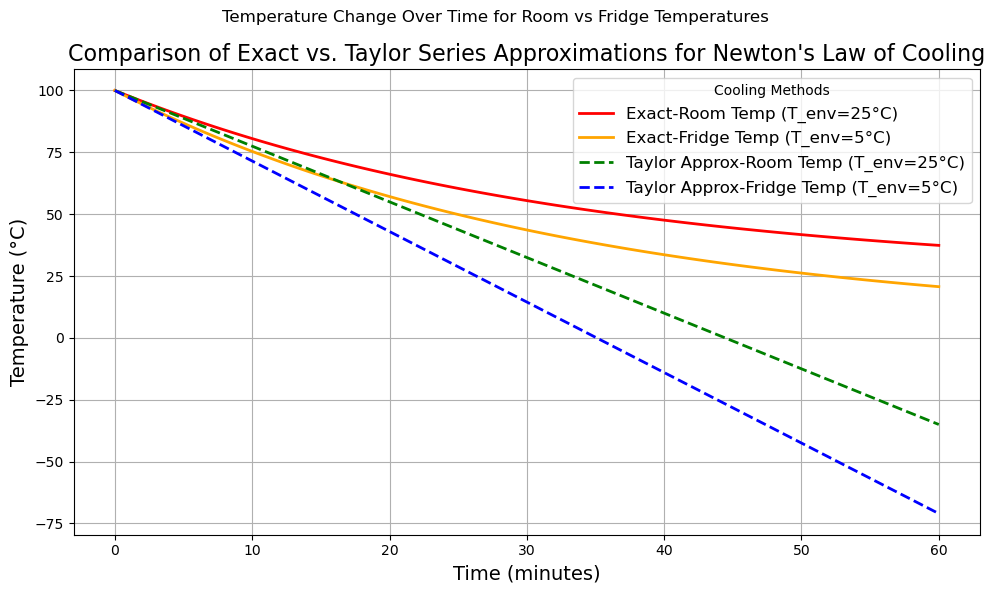

In [29]:
# Compute temperatures over time with different ambient temperatures
# Exact approximation
T_room = newton_cooling(t,T0,T_env1,k_slow)
T_fridge = newton_cooling(t,T0,T_env2,k_slow)
# Taylor Series approximation
T_room_taylor = newton_cooling_taylor(t,T0,T_env1,k_slow)
T_fridge_taylor = newton_cooling_taylor(t,T0,T_env2,k_slow)

# Create the plot
plt.figure(figsize=(10, 6)) 

# Plot the exact solutions 
plt.plot(t, T_room, label=f'Exact-Room Temp (T_env={T_env1}°C)', color='red', linestyle='-', linewidth=2)
plt.plot(t, T_fridge, label=f'Exact-Fridge Temp (T_env={T_env2}°C)', color='orange', linestyle='-', linewidth=2)

# Plot the Taylor series approximations
plt.plot(t, T_room_taylor, label=f'Taylor Approx-Room Temp (T_env={T_env1}°C)', color='green', linestyle='--', linewidth=2)
plt.plot(t, T_fridge_taylor, label=f'Taylor Approx-Fridge Temp (T_env={T_env2}°C)', color='blue', linestyle='--', linewidth=2)

# Add title and labels
plt.title("Comparison of Exact vs. Taylor Series Approximations for Newton's Law of Cooling", fontsize=16)
plt.suptitle("Temperature Change Over Time for Room vs Fridge Temperatures", fontsize=12)
plt.xlabel("Time (minutes)", fontsize=14)
plt.ylabel("Temperature (°C)", fontsize=14)

# Add a grid and legend
plt.grid(True)
plt.legend(title="Cooling Methods", fontsize=12)

# Display the plot
plt.tight_layout()  
plt.show()

#### Behaviour
The exact solutions using Newton’s Law of Cooling (represented by red and orange curves) follow an exponential decay which shows the cooling slows down over time and asymptotically approaches the ambient temperatures. Unlike it, the first-order Taylor series approximation (represented by green and blue curves) produces a linear model that fails to show the exponential cooling behaviour. While it is an accurate approximation for small $t$ (around 0-10 minutes), it increasingly underestimates the cooling effect as $t$ grows. The linear approximation eventually continues below the ambient temperature, decreasing constantly, and even becoming negative, which is not physically realistic. In contrast, the exponential function never decreases below the ambient temperature. 

#### Conclusion
When using a truncated Taylor series approximation (only the first two nonzero terms), we approximate an infinite sum with a finite sum. This will introduce computational error as higher-order terms are ignored which would improve the accuracy of approximating the exponential. Having a higher cooling factor ($k$) leads to higher computational error which is reflected in the first plot as the Taylor series approximation is enable to accurately approximate the exponential. 

All in all, the exact solutions using Newton's Law of Cooling (represented by the red and orange curves) accurately capture the cooling process, showing exponential decay and the gradual approach towards the ambient temperature, without ever dropping below it. 

On the other hand, the first-order Taylor series approximation (represented by the green and blue curves) produces a linear model, although it remains accurate for small time intervals (around 5-10 minutes), however, it gets more inaccurate as time goes on, leading to unrealistic predictions where the temperature drops below the ambient temperature. 

# Part 3: Introducing Data Errors (3 Marks)

The situation gets worse! The computer your code will be deployed on is also limited in its precision. All floating point numbers will be rounded by chopping to 3 digits of precision (in base 10). 

Once again, modify your code from part 1 ($\textbf{not}$ part 2) to take this into account. Explore the same space you did in part 1 with new plots. How and why does the behaviour change?

(Hint: after each computation, make sure to round the result)

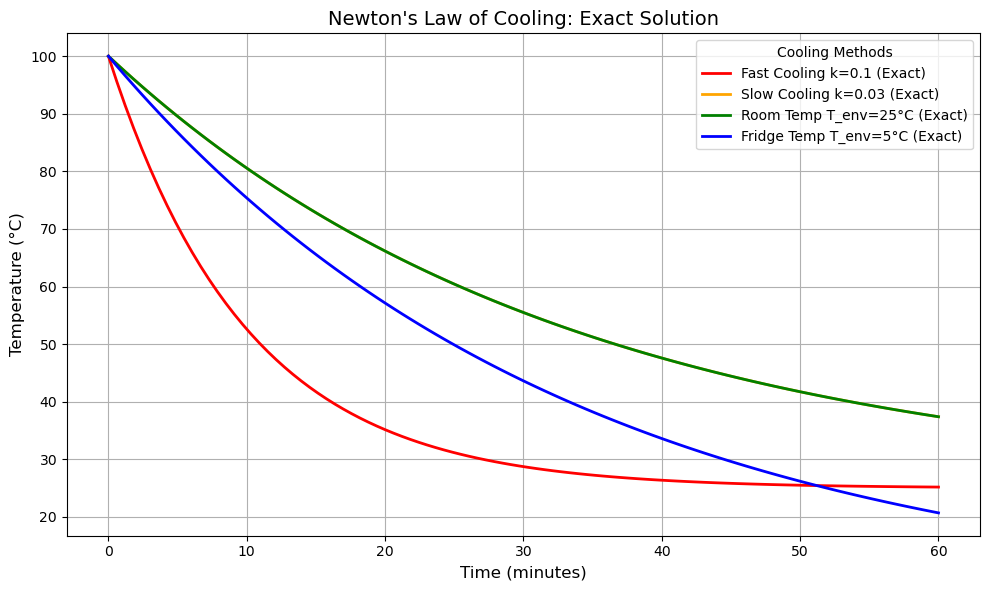

In [58]:
# Round inputs to 3 digits
def chop_to_3_digits(x, p=3):
    if x == 0:  # Special case for zero
        return 0.0
    sgn = np.where(x < 0, -1, 1)  # Get sign
    x *= sgn  # Absolute value
    e = np.floor(np.log10(x)) # Exponent
    factor = 10**(p-1-e) # Scale factor to shift decimal place
    chopped_m = np.floor(x * factor) / factor # Shift right, chops & shift back
    chopped_x = sgn * chopped_m  # Restore sign
    return chopped_x

def newton_cooling_chop(t, T0, T_env, k):
    T0 = chop_to_3_digits(T0)
    T_env = chop_to_3_digits(T_env)
    k = chop_to_3_digits(k)

    T = []
    
    # Compute temperature at each time step with rounding
    for i in range(len(t)):
        t_i = chop_to_3_digits(t[i])  # Round time
        exponent = chop_to_3_digits(-k * t_i)  # Round exponent
        exp_term = chop_to_3_digits(np.exp(exponent))  # Round exponential term
        delta_T = chop_to_3_digits(T0 - T_env)  # Round temperature difference
        product = chop_to_3_digits(delta_T * exp_term)  # Round product
        T.append(chop_to_3_digits(T_env + product))  # Round final temperature
    
    return np.array(T)

def newton_cooling(t, T0, T_env, k):
    return T_env + (T0 - T_env) * np.exp(-k * t)

# Time range & parameters
t = np.linspace(0, 60, 100)
T0 = 100
T_env1 = 25
T_env2 = 5
k_fast = 0.1
k_slow = 0.03

# Compute exact solutions using Newton's Law of Cooling
T_fast = newton_cooling(t, T0, T_env1, k_fast)
T_slow = newton_cooling(t, T0, T_env1, k_slow)
T_room = newton_cooling(t, T0, T_env1, k_slow)
T_fridge = newton_cooling(t, T0, T_env2, k_slow)

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot the exact solutions
plt.plot(t, T_fast, label=f'Fast Cooling k={k_fast} (Exact)', color='red', linewidth=2)
plt.plot(t, T_slow, label=f'Slow Cooling k={k_slow} (Exact)', color='orange', linewidth=2)
plt.plot(t, T_room, label=f'Room Temp T_env={T_env1}°C (Exact)', color='green', linewidth=2)
plt.plot(t, T_fridge, label=f'Fridge Temp T_env={T_env2}°C (Exact)', color='blue', linewidth=2)

# Adding title and labels
plt.title("Newton's Law of Cooling: Exact Solution", fontsize=14)
plt.xlabel('Time (minutes)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)

# Adding grid and legend
plt.grid(True)
plt.legend(title='Cooling Methods', fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()

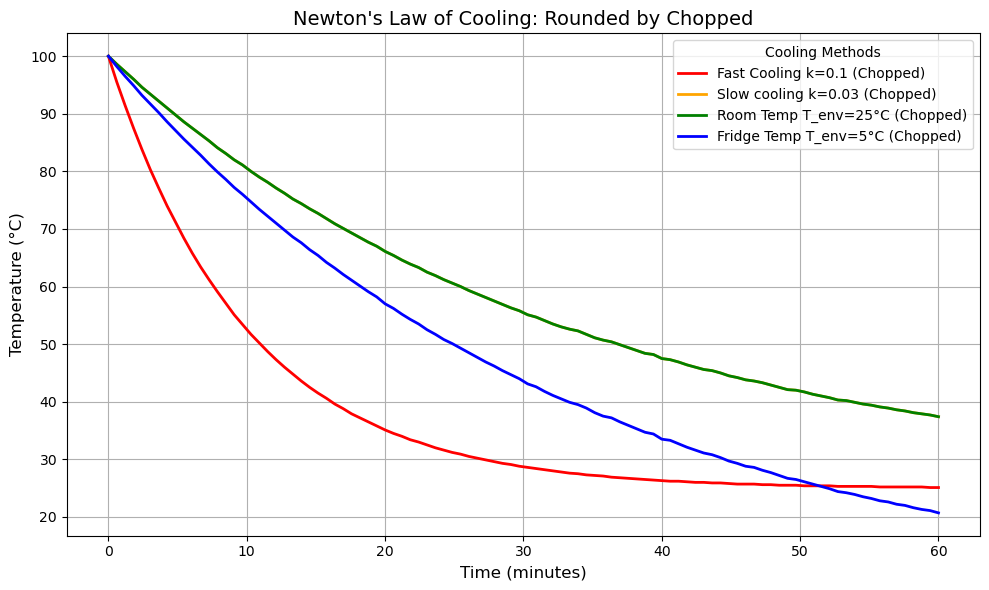

In [60]:
# Compute rounded by chopping of Newton's Law of of Cooling
T_fast_chop = newton_cooling_chop(t, T0, T_env1, k_fast)
T_slow_chop = newton_cooling_chop(t, T0, T_env1, k_slow)
T_room_chop = newton_cooling_chop(t, T0, T_env1, k_slow)
T_fridge_chop = newton_cooling_chop(t, T0, T_env2, k_slow)

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot the rounded solutions
plt.plot(t, T_fast_chop, label=f'Fast Cooling k={k_fast} (Chopped)', color='red', linewidth=2)
plt.plot(t, T_slow_chop, label=f'Slow cooling k={k_slow} (Chopped)', color='orange', linewidth=2)
plt.plot(t, T_room_chop, label=f'Room Temp T_env={T_env1}°C (Chopped)', color='green', linewidth=2)
plt.plot(t, T_fridge_chop, label=f'Fridge Temp T_env={T_env2}°C (Chopped)', color='blue', linewidth=2)

# Adding title and labels
plt.title("Newton's Law of Cooling: Rounded by Chopped", fontsize=14)
plt.xlabel('Time (minutes)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)

# Adding grid and legend
plt.grid(True)
plt.legend(title='Cooling Methods', fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()

#### Behaviour
Rounding to three significant digits reduces precision and introduces small errors that accumulate over time, causing flunctuation from the exact solution. This can be seen in the second plot, which displays small fluctuations, particularly at larger values of $t$ (after 30 minutes). However, for small $t$, the rounding errors are minimal, and the approximation remains accurate. In contrast, the first plot is smooth and continuous, accurately reflecting the true exponential nature of the cooling process.

#### Conclusion
Data Error occurs when the input data is truncated, leading to inaccuracies in the results. These errors are often caused by limitations of how computers handle floating-point numbers (e.g. IEEE 754 standard). Rounding floating-point numbers to three significant digits reduces precision and causes small fluctuation from the exact solution. 
Over time, these rounding errors accumulate, leading to noticeable fluctuations in the temperature curves, especially for larger values of $t$. For smaller values of $t$, the rounding errors are minimal, and the approximation remains relatively accurate. The original plots show a smooth and continuous exponential nature of the cooling process. In contrast, the rounded plots introduce small errors and cause fluctuation. 

# Part 4: Total Error (3 Marks)

You now wish to know how bad things will be when both the data and computational errors are taken into account. Combine your approximations for part 2 and part 3 and investigate the result. Explore the same space you did in part 1 with new plots. How and why does the behaviour change?

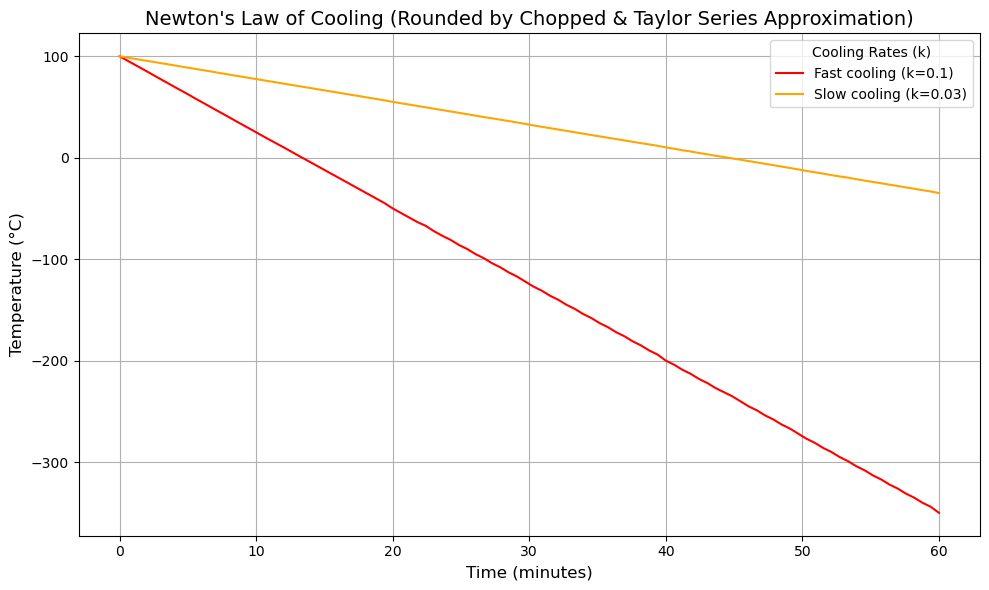

In [3]:
# Rounded by chopping into 3 digits of precision
def chop_to_3_digits(x, p=3):
    if x == 0:  # Special case for zero
        return 0.0
    sgn = np.where(x < 0, -1, 1)  # Get sign
    x *= sgn  # Absolute value
    e = np.floor(np.log10(x)) # Exponent
    factor = 10**(p-1-e) # Scale factor to shift decimal place
    chopped_m = np.floor(x * factor) / factor # Shift right, chops & shift back
    chopped_x = sgn * chopped_m  # Restore sign #######
    return chopped_x

# Newton's Law of Cooling with rounded by chopped & Taylor Series approximation
def newton_cooling_chop_taylor(t, T0, T_env, k):
    T0 = chop_to_3_digits(T0)
    T_env = chop_to_3_digits(T_env)
    k = chop_to_3_digits(k)

    T = []
    
    for i in range(len(t)):
        t_i = chop_to_3_digits(t[i])  # Round time
        exponent = chop_to_3_digits(1 - k * t_i)  # Round exponent
        delta_T = chop_to_3_digits(T0 - T_env)  # Round temperature difference
        product = chop_to_3_digits(delta_T * exponent)  # Round product
        T.append(chop_to_3_digits(T_env + product))  # Round final temperature
    
    return np.array(T)


# def newton_cooling_taylor(t,T0,T_env,k):
#     return T_env + (T0 - T_env) * (1 - k*t)

# Time range & parameters
t = np.linspace(0, 60, 100)
T0 = 100
T_env1 = 25  # Room temperature
T_env2 = 5   # Fridge temperature
k_fast = 0.1  # Metal cup
k_slow = 0.03  # Ceramic mug

# Compute rounded by chopping & Taylor Series approximation of Newton's Law of Cooling
# Different Cooling Rates (k)
T_fast_chop_taylor = newton_cooling_chop_taylor(t, T0, T_env1, k_fast)
T_slow_chop_taylor = newton_cooling_chop_taylor(t, T0, T_env1, k_slow)

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot the rounded solutions
plt.plot(t, T_fast_chop_taylor, color='red', label=f'Fast cooling (k={k_fast})')
plt.plot(t, T_slow_chop_taylor, color='orange', label=f'Slow cooling (k={k_slow})')

# Adding title and labels
plt.title("Newton's Law of Cooling (Rounded by Chopped & Taylor Series Approximation)", fontsize=14)
plt.xlabel("Time (minutes)", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)

# Adding grid and legend
plt.grid(True)
plt.legend(title='Cooling Rates (k)', fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()

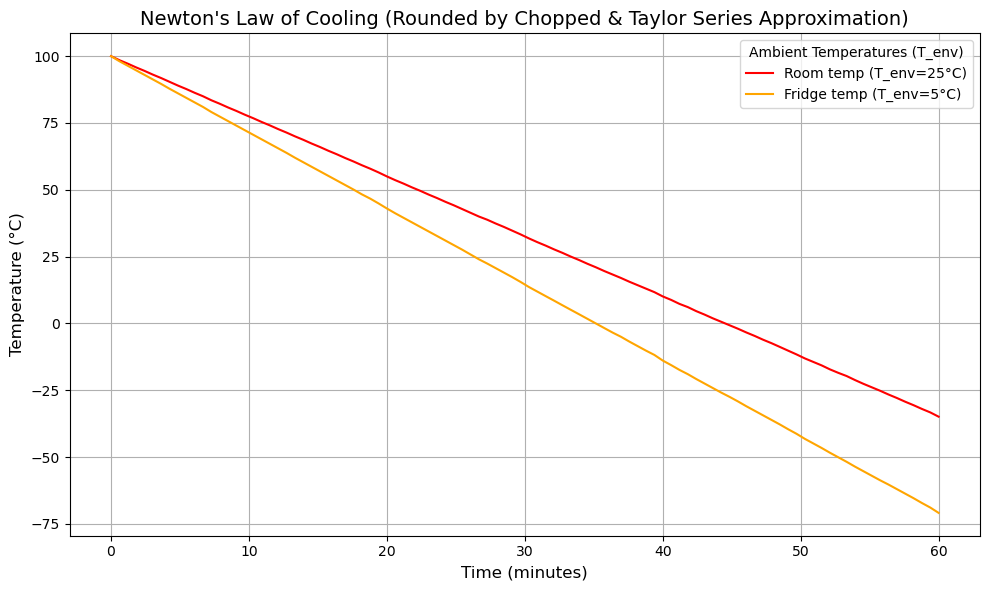

In [4]:
# Compute rounded by chopping & Taylor Series approximation of Newton's Law of Cooling
# Different Ambient Temperature (T_env)
T_room_chop_taylor = newton_cooling_chop_taylor(t, T0, T_env1, k_slow)
T_fridge_chop_taylor = newton_cooling_chop_taylor(t, T0, T_env2, k_slow)

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot the rounded solutions
plt.plot(t, T_room_chop_taylor, color='red', label=f'Room temp (T_env={T_env1}°C)')
plt.plot(t, T_fridge_chop_taylor, color='orange', label=f'Fridge temp (T_env={T_env2}°C)')

# Adding title and labels
plt.title("Newton's Law of Cooling (Rounded by Chopped & Taylor Series Approximation)", fontsize=14)
plt.xlabel("Time (minutes)", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)

# Adding grid and legend
plt.grid(True)
plt.legend(title='Ambient Temperatures (T_env)', fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()

#### Behaviour of both plots
The first plot indicates that higher cooling rates will reach a lower temperature than the object in the room temperature. The second plot indicates that having a lower ambient temperature will cool the object faster than having a higher ambient temperature

In both plots, the combined effect of truncating the Taylor series and rounding computations causes more errors, as it shows a gradual decrease that appears linear with fluctuations. On the contrary, the part 1 plot shows a smooth exponential curve for the cooling process. The combined errors can lead to inaccuracies in predicting the exact temperature at any given time, especially for longer durations and may lead to unrealistic predictions. 

#### Conclusion
The total error is the sum of data error (caused by rounding via chopping) and computational error (caused by Taylor Series truncation), leading to inaccuracies in temperature predictions and linear curves with small fluctuations. Compared to Part 1, which shows a smooth cooling curve, these plots have fluctuations and less accuracy. This indicates that rounding by chopping and Taylor Series can lead to errors in predicting temperature changes. 

# Part 5: Sensitivity and Conditioning (3 Marks)

You wish to advise users on where your model can be trusted, and where the results should be suspect. To do this you must in some way estimate the conditioning of this problem. How and why does the conditioning of the problem vary over the domain? When should one trust the output of your code?

Use both the approximate form of the condition number;

$CN(f(x)) \approx \left | \frac{xf'(x)}{f(x)} \right |$

and the exact form; 

$CN(f(x)) = \left |\frac{\frac{f(x) - \hat{f}(\hat{x})}{f(x)}}{\frac{x - f^{-1}(\hat {f} (\hat{x}))}{x}} \right |$

and compare the results. If either formulation of the condition number is not appropriate for your function, do not use it, and explain your reasoning for doing so. 

#### Approximate Form of the Condition Number
It's good for quick estimation, and the functions plotted are smooth; however, it doesn't reflect the small fluctuations caused by the total error, which includes data error and computational error. It works well for small perturbations in $x$ but doesn't account for larger errors. The derivative helps us to understand how much the function changes as $t$ changes. It is an estimate of how sensitive the function is to small changes in its input at a particular point.

If $CN(f(x))$ is large, even a tiny change in $x$ causes a big change in $f(x)$. This means the function is sensitive <br>
If $CN(f(x))$ is small, changes in $x$ have a small impact, meaning the function is stable.

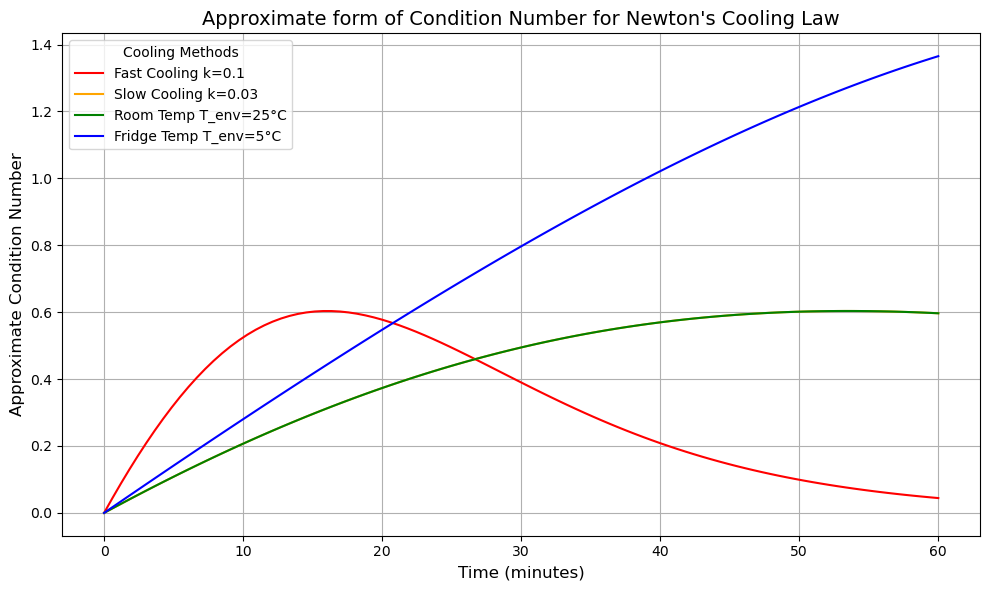

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# Newton's law of Cooling 
def newton_cooling(t, T0, T_env, k):
    return T_env + (T0 - T_env) * np.exp(-k * t)

# Derivative of the Function
def newton_cooling_derivative(t, T0, T_env, k):
    return -k * (T0 - T_env) * np.exp(-k * t)

# Approximate form of condition number
def approx_condition_number(t, T0, T_env, k):
    f_t = newton_cooling(t, T0, T_env, k)
    f_prime_t = newton_cooling_derivative(t, T0, T_env, k)
    return np.abs(t * f_prime_t / f_t)

# Time range & parameters
t = np.linspace(0, 60, 100)
T0 = 100
T_env1 = 25  # Room temperature
T_env2 = 5   # Fridge temperature
k_fast = 0.1  # Metal cup
k_slow = 0.03  # Ceramic mug

# Compute the approximate form of condition number
CN_approx_fast = approx_condition_number(t, T0, T_env1, k_fast)
CN_approx_slow = approx_condition_number(t, T0, T_env1, k_slow)
CN_approx_room = approx_condition_number(t, T0, T_env1, k_slow)
CN_approx_fridge = approx_condition_number(t, T0, T_env2, k_slow)

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot the approximate form of condition number
plt.plot(t, CN_approx_fast, color='red', label=f"Fast Cooling k={k_fast}")
plt.plot(t, CN_approx_slow, color='orange', label=f"Slow Cooling k={k_slow}")
plt.plot(t, CN_approx_room, color='green', label=f"Room Temp T_env={T_env1}°C")
plt.plot(t, CN_approx_fridge, color='blue', label=f"Fridge Temp T_env={T_env2}°C")

# Adding title and labels
plt.title("Approximate form of Condition Number for Newton's Cooling Law", fontsize=14)
plt.xlabel("Time (minutes)", fontsize=12)
plt.ylabel("Approximate Condition Number", fontsize=12)

# Adding grid and legend
plt.grid(True)
plt.legend(title='Cooling Methods', fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()

#### Exact Form of the Condition Number
It measures the impact of the numerical perturbations and compares the total error to the true value $f(x)$. It captures the limits of computer and real-world numerical effects, which incorporate rounding, chopping and floating-point precision errors. It is more accurate and uses the inverse function, which tells us what time corresponds to a given temperature. It calculates the relative change in both the input and output, taking into account how small errors propagate through the function. 

If $CN(f(x))$ is large, even a small error in the input creates a large error in the output <br>
If $CN(f(x))$ is small, the function is stable and handles errors well

100.0 25.0 0.1
100.0 25.0 0.03
100.0 25.0 0.03
100.0 5.0 0.03


C:\Users\USER\AppData\Local\Temp\ipykernel_21488\4131137079.py:39: RuntimeWarning: divide by zero encountered in divide
  return np.abs( ((T_t - T_chopped)/T_t) / ((t - t_perturbed)/t) )


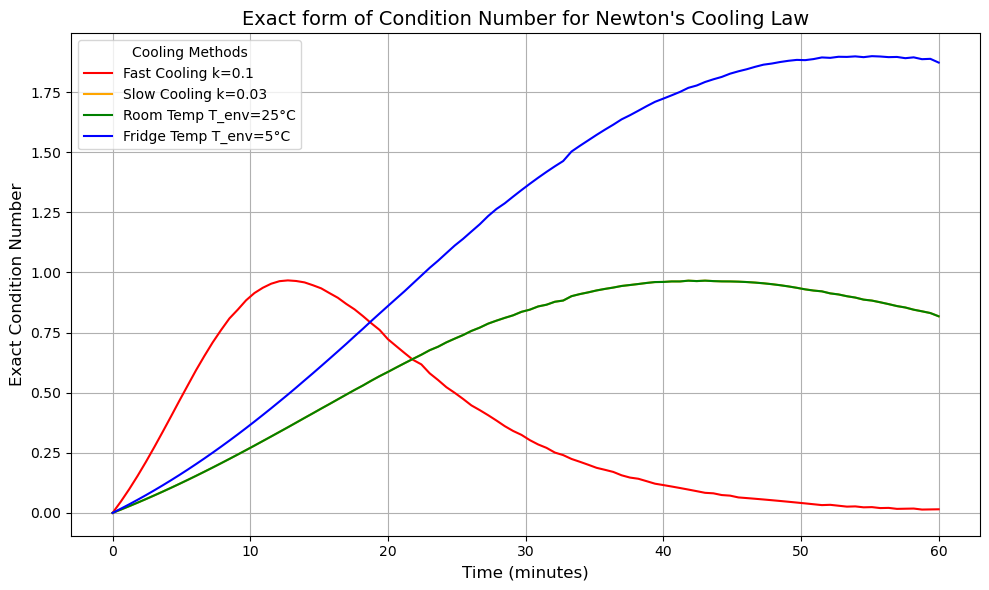

In [76]:
# CHOPPED FUNCTION
def chop_to_3_digits(x, p=3):
    if x == 0:  # Special case for zero
        return 0.0
    sgn = np.where(x < 0, -1, 1)  # Get sign
    x *= sgn  # Absolute value
    e = np.floor(np.log10(x)) # Exponent
    factor = 10**(p-1-e) # Scale factor to shift decimal place
    chopped_m = np.floor(x * factor) / factor # Shift right, chops & shift back
    chopped_x = sgn * chopped_m  # Restore sign
    return chopped_x

def newton_cooling_chop_taylor(t, T0, T_env, k):
    T0 = chop_to_3_digits(T0)
    T_env = chop_to_3_digits(T_env)
    k = chop_to_3_digits(k)

    print(T0, T_env, k)

    T = []
    
    # Compute temperature at each time step with rounding
    for i in range(len(t)):
        t_i = chop_to_3_digits(t[i])  # Round time
        exponent = chop_to_3_digits(1 - k * t_i)  # Round exponent
        exp_term = chop_to_3_digits(np.exp(exponent))  # Round exponential term
        delta_T = chop_to_3_digits(T0 - T_env)  # Round temperature difference
        product = chop_to_3_digits(delta_T * exp_term)  # Round product
        T.append(chop_to_3_digits(T_env + product))  # Round final temperature
    
    return np.array(T)

# Exact form of condition number
def exact_condition_number(t, T0, T_env, k):
    T_t = newton_cooling(t, T0, T_env, k)
    T_chopped = newton_cooling_chop_taylor(t,T0,T_env,k)
    T_inv = lambda T: ((T0-T)/(k*(T0-T_env)))
    t_perturbed = T_inv(T_chopped)  
    return np.abs( ((T_t - T_chopped)/T_t) / ((t - t_perturbed)/t) )

# Compute the exact form of condition number
CN_exact_fast = exact_condition_number(t, T0, T_env1, k_fast)
CN_exact_slow = exact_condition_number(t, T0, T_env1, k_slow)
CN_exact_room = exact_condition_number(t, T0, T_env1, k_slow)
CN_exact_fridge = exact_condition_number(t, T0, T_env2, k_slow)

# Plotting the results
plt.figure(figsize=(10, 6))

# Plot the approximate condition number
plt.plot(t, CN_exact_fast, color='red', label=f"Fast Cooling k={k_fast}")
plt.plot(t, CN_exact_slow, color='orange', label=f"Slow Cooling k={k_slow}")
plt.plot(t, CN_exact_room, color='green', label=f"Room Temp T_env={T_env1}°C")
plt.plot(t, CN_exact_fridge, color='blue', label=f"Fridge Temp T_env={T_env2}°C")

# Adding title and labels
plt.title("Exact form of Condition Number for Newton's Cooling Law", fontsize=14)
plt.xlabel("Time (minutes)", fontsize=12)
plt.ylabel("Exact Condition Number", fontsize=12)

# Adding grid and legend
plt.grid(True)
plt.legend(title='Cooling Methods', fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()

#### Compare the result
Both plots have similar curves. The only difference is that in the exact form of condition number (second plot), there are some small fluctuations, whereas the approximate form of condition number (first plot) has a smooth curve. The difference arises as the exact form of the condition number (second plot) accounts for the total error. Additionally, when $t$ is about 50-60 minutes, the peak of the condition number slightly decreases in the exact version, whereas the approximate version continues to increase.

#### How and why does the conditioning of the problem vary over the domain? 
The variation in conditioning is influenced by the mathematical structure of the function, such as the presence of $exp$, $log$, etc. By finding the condition, it can lead us to identify the regions where small errors in input can lead to large errors in output.

##### Initially
The condition number is small as the function behaves predictably.

##### When $t$ is about 5-20 minutes
The condition number increases steadily as the temperature of the object cools rapidly over that duration of t, which can be observed at Part 1. However, for fast cooling ($k$= 0.1, red curve), it reaches its peak when $t$ is around 12 minutes. This might be due rate of change of temperature being large in that duration of $t$.

##### When $t$ is over 20 minutes
The condition number decreases and stabilizes for fast cooling ($k$= 0.1, red curve) while for slow cooling ($k$=0.03, orange curve), room temperature ($T_{env}$ = 25°C, green curve) and fridge temperature ($T_{env}$ = 5°C, blue curve), it increase significantly and stabilizes when $t$ is around 50 minutes as the object gets closer to the ambient temperature.

There is an error that shows "divide by zero encountered in divide". This occurs because dividing by 0 will result in undefined as it's going to infinity.

#### When should one trust the output of your code?
We can trust the output when the condition number is well-conditioned (<= 1.0). This means the function is not sensitive and small errors in input do not significantly affect the output. However, when the condition number is ill-conditioned (> 1.0), we should not trust the output, as it means small errors can lead to large output variations.

The red, orange and green curves, the condition number it's <= 1.0; thus, we can trust the output as it's not sensitive and is well-conditioned. We should not trust the blue curve when $t$ is over 20 minutes, as the condition number is > 1.0; it linearly increases when $t$ increases. 

#### Conclusion
The approximate condition number provides a quick estimation of sensitivity when working with small changes in input. The exact condition number accounts for real-world numerical effects, including floating-point errors, and is more accurate and precise to track how errors affect computations. The condition number helps identify regions where the function is well-conditioned ($CN(f(x))$ ≤ 1.0) and reliable, versus ill-conditioned ($CN(f(x))$ > 1.0), where small errors can cause significant instability. 

# AI Statement

Very briefly explain the ways that you have used AI in the production of this assessment.

Explain which AI tools you have used and for what purposes.
If you have found and used tools on your own, explain why these tools were selected and provide a URL link to the tool.
Note the number of iterations undertaken with each main AI collaborative tool.
Describe what output from the tool/service has been included, and where.
Summarise how you have altered, adopted, or built on the AI output.

(See Monash Guidelines available at https://www.monash.edu/student-academic-success/build-digital-capabilities/create-online/acknowledging-the-use-of-generative-artificial-intelligence)



### Acknowledge
I acknowledge the use of ChatGPT(https://chat.openai.com/) 
##### i) To refine my own work and academic language
I submitted the analysis I wrote for each plot with instructions to improve my phrasing, vocabulary, and language accuracy (2 iterations). I further rephrased to represent my tone and style of writing.

##### ii) To understand both the exact and approximate form of the condition number
I submitted the exact and approximate form of the condition number to help understand the formulas with simplified explanations (3 iterations). I further edited my comparison and analysis of both forms and added more explanation to it. 


### References
Other than ChatGPT, I also referenced the following websites for understanding Newton's Law of Cooling:

GeeksforGeeks. (n.d.). Newton’s law of cooling. https://www.geeksforgeeks.org/newtons-law-of-cooling/

Amrita Vishwa Vidyapeetham Virtual Labs. (n.d.). Newton’s law of cooling. https://vlab.amrita.edu/?sub=3&brch=194&sim=354&cnt=1#:~:text=Newton's%20Law%20of%20Cooling%20is,when%20you%20go%20on%20vacation.
